In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure backend environment paths
sys.path.append(os.path.abspath(os.path.join('..', 'backend')))

from app.ai.sentiment import predict_sentiment
print("Sentiment analysis environment ready.")

Sentiment analysis environment ready.


In [2]:
# Load a subset of real text data to analyze sentiment trends
df = pd.read_csv("../data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")
sample_df = df.sample(n=300, random_state=42).copy()

sentiments = []
scores = []

print("Analyzing sentiment distributions across 300 samples...")
for idx, row in sample_df.iterrows():
    res = predict_sentiment(row['instruction'])
    sentiments.append(res['sentiment'])
    scores.append(res.get('score', 1.0)) # Default score if fallback is used

sample_df['predicted_sentiment'] = sentiments
sample_df['sentiment_score'] = scores
print("Analysis complete!")

Analyzing sentiment distributions across 300 samples...
Analysis complete!


C:\Users\Dell\AppData\Local\Temp\ipykernel_2960\2456473468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sample_df, x='predicted_sentiment', palette='viridis', order=['Positive', 'Neutral', 'Negative'])


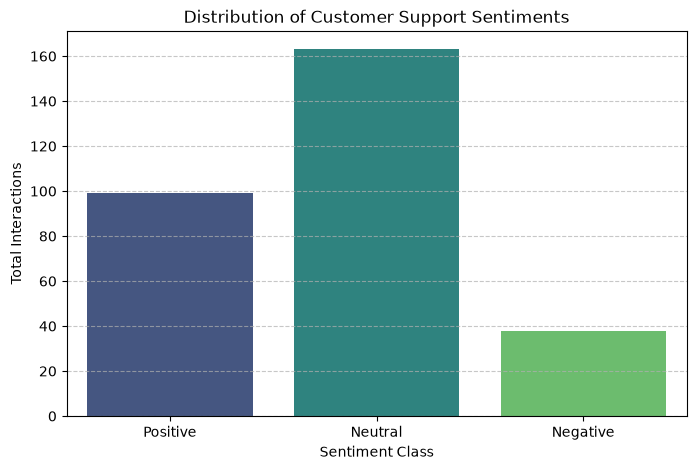

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=sample_df, x='predicted_sentiment', palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Distribution of Customer Support Sentiments')
plt.xlabel('Sentiment Class')
plt.ylabel('Total Interactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
# Let's test how our system handles aggressive or anxious vocabulary
edge_cases = [
    "I am extremely angry! You double charged my card!",
    "Thank you, this solved my problem instantly.",
    "I guess it's fine, but the delivery took forever.",
    "Please tell me my order is coming today, I am worried."
]

print("=== EDGE CASE SENTIMENT EVALUATION ===")
for text in edge_cases:
    result = predict_sentiment(text)
    print(f"Text: '{text}' -> Sentiment: {result['sentiment']}")

=== EDGE CASE SENTIMENT EVALUATION ===
Text: 'I am extremely angry! You double charged my card!' -> Sentiment: Negative
Text: 'Thank you, this solved my problem instantly.' -> Sentiment: Positive
Text: 'I guess it's fine, but the delivery took forever.' -> Sentiment: Positive
Text: 'Please tell me my order is coming today, I am worried.' -> Sentiment: Neutral
